In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df.drop(columns=["PE"])
Y=df["PE"]

In [ ]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

In [ ]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test,dtype=torch.float32)

In [ ]:
Y_train_tensor=torch.tensor(y_train,dtype=torch.float32)
Y_test_tensor=torch.tensor(y_test,dtype=torch.float32)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

In [ ]:
train_Loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_Loader=DataLoader(test_dataset,batch_size=32,shuffle=True)


In [ ]:
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
import torch.optim as optim

model = ANNModel(input_size=X_train.shape[1])

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 100

train_losses = []   # stores training loss per epoch
valid_losses = []   # stores validation loss per epoch
bestEpoch=float('inf')
for epoch in range(epochs):

    # -------- TRAINING --------
    model.train()   # set model to training mode

    running_loss = 0.0   # total training loss for this epoch

    for xb, yb in train_Loader:

        optimizer.zero_grad()   # clear previous gradients

        pred = model(xb)        # forward pass
        loss = criterion(pred, yb)   # compute loss

        loss.backward()   # compute gradients
        optimizer.step()  # update weights

        running_loss += loss.item()   # accumulate batch loss

    # average training loss
    epochtrainloss = running_loss / len(train_Loader)
    train_losses.append(epochtrainloss)


    # -------- VALIDATION --------
    model.eval()   # set model to evaluation mode

    running_valid_loss = 0.0   # total validation loss

    with torch.no_grad():   # no gradient calculation
        for xb, yb in test_Loader:

            pred = model(xb)   # forward pass
            loss = criterion(pred, yb)

            running_valid_loss += loss.item()

    # average validation loss
    epochvalidloss = running_valid_loss / len(test_Loader)
    valid_losses.append(epochvalidloss)


    # -------- PRINT --------
    print(f"Epoch {epoch+1} | Train Loss: {epochtrainloss:.4f} | Val Loss: {epochvalidloss:.4f}")
    if bestEpoch>epochvalidloss:
      bestEpoch=epochvalidloss
      torch.save(model.state_dict(), "best_model.pth")

Epoch 1 | Train Loss: 0.1260 | Val Loss: 0.0607
Epoch 2 | Train Loss: 0.0638 | Val Loss: 0.0569
Epoch 3 | Train Loss: 0.0641 | Val Loss: 0.0585
Epoch 4 | Train Loss: 0.0633 | Val Loss: 0.0611
Epoch 5 | Train Loss: 0.0625 | Val Loss: 0.0577
Epoch 6 | Train Loss: 0.0626 | Val Loss: 0.0647
Epoch 7 | Train Loss: 0.0621 | Val Loss: 0.0643
Epoch 8 | Train Loss: 0.0623 | Val Loss: 0.0564
Epoch 9 | Train Loss: 0.0609 | Val Loss: 0.0597
Epoch 10 | Train Loss: 0.0626 | Val Loss: 0.0587
Epoch 11 | Train Loss: 0.0604 | Val Loss: 0.0563
Epoch 12 | Train Loss: 0.0620 | Val Loss: 0.0576
Epoch 13 | Train Loss: 0.0617 | Val Loss: 0.0699
Epoch 14 | Train Loss: 0.0626 | Val Loss: 0.0554
Epoch 15 | Train Loss: 0.0608 | Val Loss: 0.0545
Epoch 16 | Train Loss: 0.0603 | Val Loss: 0.0561
Epoch 17 | Train Loss: 0.0602 | Val Loss: 0.0571
Epoch 18 | Train Loss: 0.0599 | Val Loss: 0.0544
Epoch 19 | Train Loss: 0.0603 | Val Loss: 0.0553
Epoch 20 | Train Loss: 0.0605 | Val Loss: 0.0560
Epoch 21 | Train Loss: 0.0596

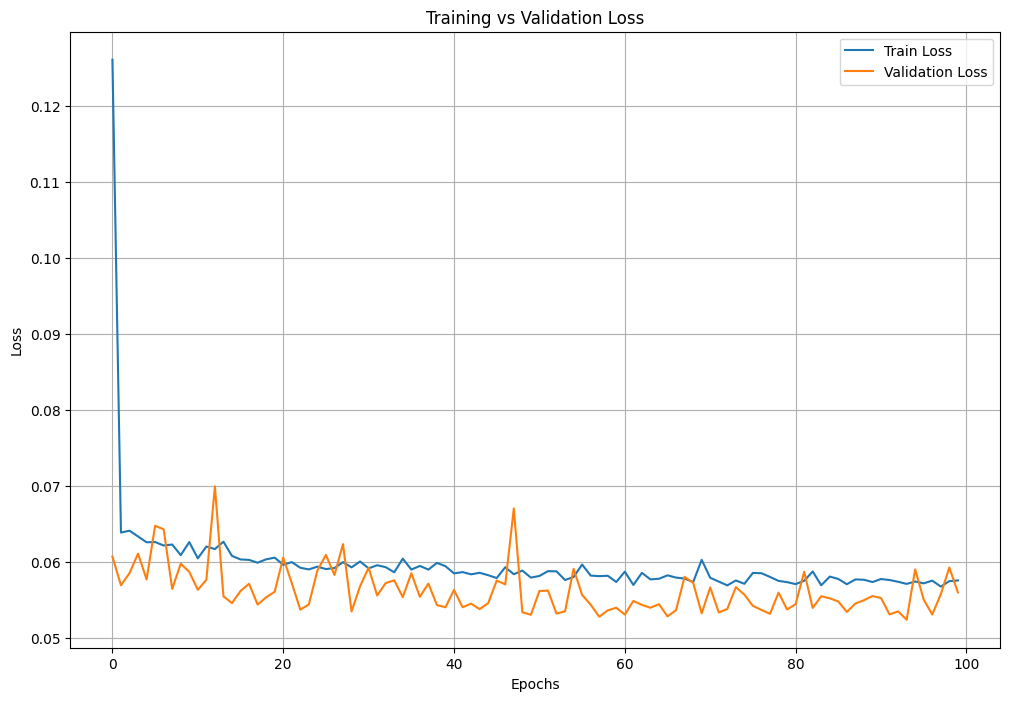

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
new_data = [[22.0, 59.0, 1010.0, 53.0]]

# scale input
new_data_scaled = scaler.transform(new_data)

# convert to tensor
new_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

# prediction
model.eval()
with torch.no_grad():
    pred = model(new_tensor)

# inverse scaling
pred_original = y_scaler.inverse_transform(pred.numpy())

print("Predicted PE:", pred_original[0][0])

Predicted PE: 450.00418


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:

checkpoint = torch.load("best_model.pth")
print(type(checkpoint))

<class 'collections.OrderedDict'>


In [ ]:
import os
print(os.path.exists("best_model.pth"))

True


In [ ]:
print(os.path.getsize("best_model.pth"))

3961


In [ ]:
model = ANNModel(input_size=X_train.shape[1])
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

ANNModel(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_train_tensor)
    msetrain = criterion(preds,Y_train_tensor)
    preds = model(X_test_tensor)
    msetest = criterion(preds,Y_test_tensor)

print("MSE:", msetrain.item())
print("MSE:", msetest.item())

MSE: 0.05458363890647888
MSE: 0.05237431824207306


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test_tensor, preds)
print("R2 Score:", r2)

R2 Score: 0.9464583165823928


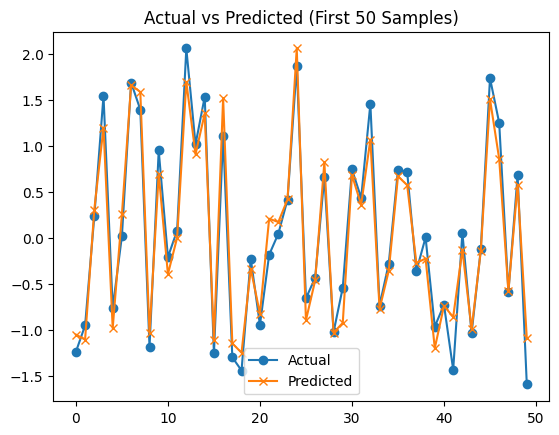

In [ ]:
import matplotlib.pyplot as plt

y_true = Y_test_tensor.cpu().numpy()
y_pred = preds.cpu().numpy()

# take only first 50 points
n = 50

plt.plot(y_true[:n], label="Actual", marker='o')
plt.plot(y_pred[:n], label="Predicted", marker='x')

plt.legend()
plt.title("Actual vs Predicted (First 50 Samples)")
plt.show()